# 乳腺肿瘤细胞核特征二分类建模实验

本 Notebook 基于本地数据 `data/model_data_cancer.csv`，构建一个完整的机器学习二分类建模对比实验，覆盖数据探索、特征工程、多模型训练与评估、超参数调优和模型解释性分析。

> 说明：本 Notebook 仅用于机器学习教学和建模流程演示，不用于医学诊断。`target` 是数据中的二分类标签，本文不擅自扩展其医学含义。

## 1. 环境与依赖

本实验使用 `pandas`、`numpy`、`matplotlib`、`seaborn`、`scikit-learn`、`statsmodels` 和 `xgboost`。

In [1]:
from pathlib import Path
import os
import tempfile
import warnings

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'cancer_ml_matplotlib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'model_data_cancer.csv'
RANDOM_STATE = 42

DATA_PATH

WindowsPath('C:/Users/烟幕/Documents/量化交易/data/model_data_cancer.csv')

## 2. 探索性数据分析（EDA）

本节按 3.1 标准完成探索性数据分析：数据基本信息、缺失值检查、目标变量分布与百分比标注、描述性统计、按 target 分组均值对比、27x27 特征相关热力图、Top-10 target 相关特征，以及关键特征按 target 分组的小提琴图/箱线图。


In [2]:
df = pd.read_csv(DATA_PATH)
print('Data shape:', df.shape)
display(df.head())
display(df.info())

Data shape: (569, 28)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean symmetry,mean fractal dimension,radius error,...,fractal dimension error,worst radius,worst texture,worst perimeter,worst smoothness,worst compactness,worst concavity,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.2419,0.07871,1.0950,...,0.006193,25.38,17.33,184.60,0.1622,0.6656,0.7119,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.1812,0.05667,0.5435,...,0.003532,24.99,23.41,158.80,0.1238,0.1866,0.2416,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.2069,0.05999,0.7456,...,0.004571,23.57,25.53,152.50,0.1444,0.4245,0.4504,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.2597,0.09744,0.4956,...,0.009208,14.91,26.50,98.87,0.2098,0.8663,0.6869,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.1809,0.05883,0.7572,...,0.005115,22.54,16.67,152.20,0.1374,0.2050,0.4000,0.2364,0.07678,0


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean symmetry            569 non-null    float64
 8   mean fractal dimension   569 non-null    float64
 9   radius error             569 non-null    float64
 10  texture error            569 non-null    float64
 11  perimeter error          569 non-null    float64
 12  area error               569 non-null    float64
 13  smoothness error         569 non-null    float64
 14  compactness error        569 non-null

None

In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()
target_counts = df['target'].value_counts().sort_index()
target_ratio = df['target'].value_counts(normalize=True).sort_index()

print('Missing values total:', int(missing_summary.sum()))
print('Duplicate rows:', int(duplicate_count))
display(pd.DataFrame({'count': target_counts, 'ratio': target_ratio}))
display(df.describe().T)

Missing values total: 0
Duplicate rows: 0


,count,ratio
target,,
0,212,0.372583
1,357,0.627417


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744
radius error,569.0,0.405172,0.277313,0.111500,0.232400,0.324200,0.478900,2.87300


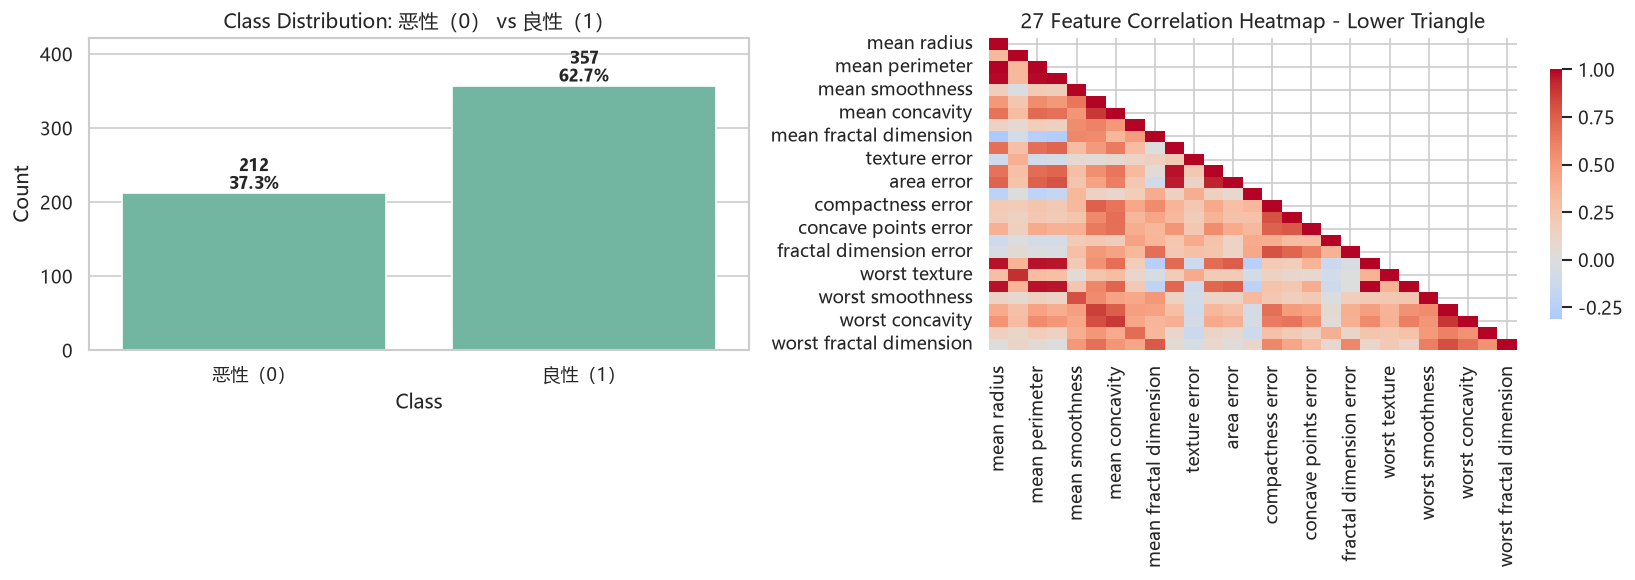

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = sorted(df['target'].unique())
ax = sns.countplot(data=df, x='target', order=order, ax=axes[0])
axes[0].set_title('Class Distribution: 恶性（0） vs 良性（1）')
axes[0].set_xlabel('Class')
axes[0].set_xticklabels(['恶性（0）', '良性（1）'])
axes[0].set_ylabel('Count')
for patch in ax.patches:
    count = int(patch.get_height())
    pct = count / len(df)
    ax.annotate(
        f'{count}\n{pct:.1%}',
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )
axes[0].set_ylim(0, target_counts.max() * 1.18)

feature_corr = df.drop(columns=['target']).corr(numeric_only=True)
upper_mask = np.triu(np.ones_like(feature_corr, dtype=bool), k=1)
sns.heatmap(feature_corr, mask=upper_mask, cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('27 Feature Correlation Heatmap - Lower Triangle')
plt.tight_layout()
plt.show()


### 2.1 按 target 分组的特征均值对比

下表比较恶性（0）与良性（1）两组在各细胞核特征上的均值差异，并计算均值差和相对差异，用来快速观察哪些特征在两类样本之间差异更明显。


In [5]:
target_mean_table = df.groupby('target')[df.drop(columns=['target']).columns].mean().T
target_mean_table.columns = [f'target_{c}_mean' for c in target_mean_table.columns]
if {'target_0_mean', 'target_1_mean'}.issubset(target_mean_table.columns):
    target_mean_table['mean_diff_1_minus_0'] = target_mean_table['target_1_mean'] - target_mean_table['target_0_mean']
    target_mean_table['abs_mean_diff'] = target_mean_table['mean_diff_1_minus_0'].abs()
    target_mean_table['relative_diff'] = target_mean_table['mean_diff_1_minus_0'] / target_mean_table['target_0_mean'].replace(0, np.nan)

target_mean_table = target_mean_table.sort_values('abs_mean_diff', ascending=False)
display(target_mean_table)


,target_0_mean,target_1_mean,mean_diff_1_minus_0,abs_mean_diff,relative_diff
mean area,978.376415,462.790196,-515.586219,515.586219,-0.526981
worst perimeter,141.370330,87.005938,-54.364392,54.364392,-0.384553
area error,72.672406,21.135148,-51.537257,51.537257,-0.709172
mean perimeter,115.365377,78.075406,-37.289971,37.289971,-0.323234
worst radius,21.134811,13.379801,-7.755010,7.755010,-0.366931
worst texture,29.318208,23.515070,-5.803138,5.803138,-0.197936
mean radius,17.462830,12.146524,-5.316306,5.316306,-0.304436
mean texture,21.604906,17.914762,-3.690144,3.690144,-0.170801
perimeter error,4.323929,2.000321,-2.323608,2.323608,-0.537383
radius error,0.609083,0.284082,-0.325000,0.325000,-0.533590


### 2.2 Top-10 与 target 最相关的特征

对每个特征计算与 `target` 的相关系数，并按绝对值排序。该分析用于筛选与分类标签关系最强的特征，便于后续模型解释和可视化。


,feature,corr_with_target
0,worst perimeter,-0.782914
1,worst radius,-0.776454
2,mean perimeter,-0.742636
3,mean radius,-0.730029
4,mean area,-0.708984
5,mean concavity,-0.696360
6,worst concavity,-0.659610
7,mean compactness,-0.596534
8,worst compactness,-0.590998
9,radius error,-0.567134


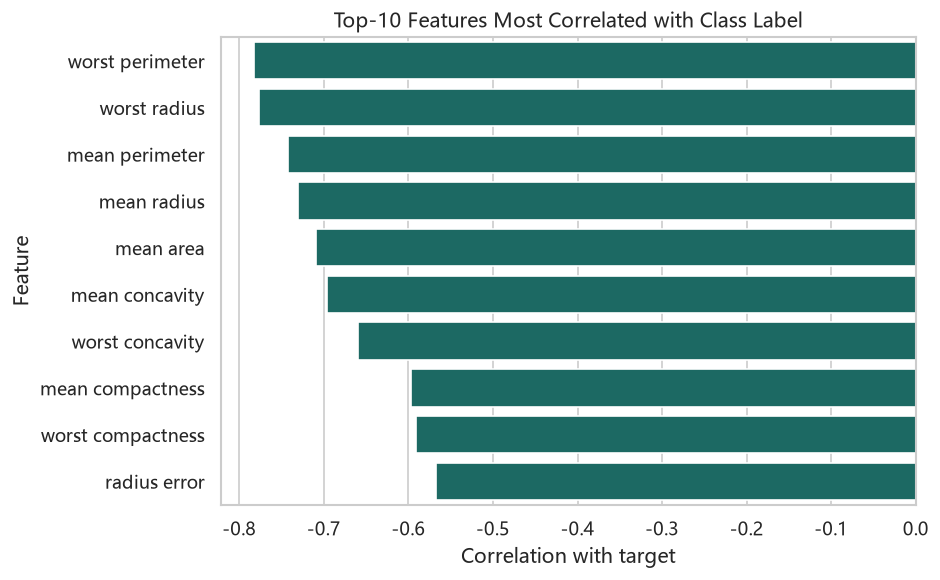

In [6]:
target_corr = df.corr(numeric_only=True)['target'].drop('target').sort_values(key=lambda s: s.abs(), ascending=False)
top_target_corr = target_corr.head(10).reset_index()
top_target_corr.columns = ['feature', 'corr_with_target']

display(top_target_corr)
plt.figure(figsize=(8, 5))
sns.barplot(data=top_target_corr, x='corr_with_target', y='feature', color='#0f766e')
plt.axvline(0, color='#667085', linewidth=1)
plt.title('Top-10 Features Most Correlated with Class Label')
plt.xlabel('Correlation with target')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 2.3 关键特征按 target 分组的分布

选择与 `target` 相关性最高的 6 个特征，分别绘制小提琴图和箱线图，观察两类样本在关键特征上的分布差异。


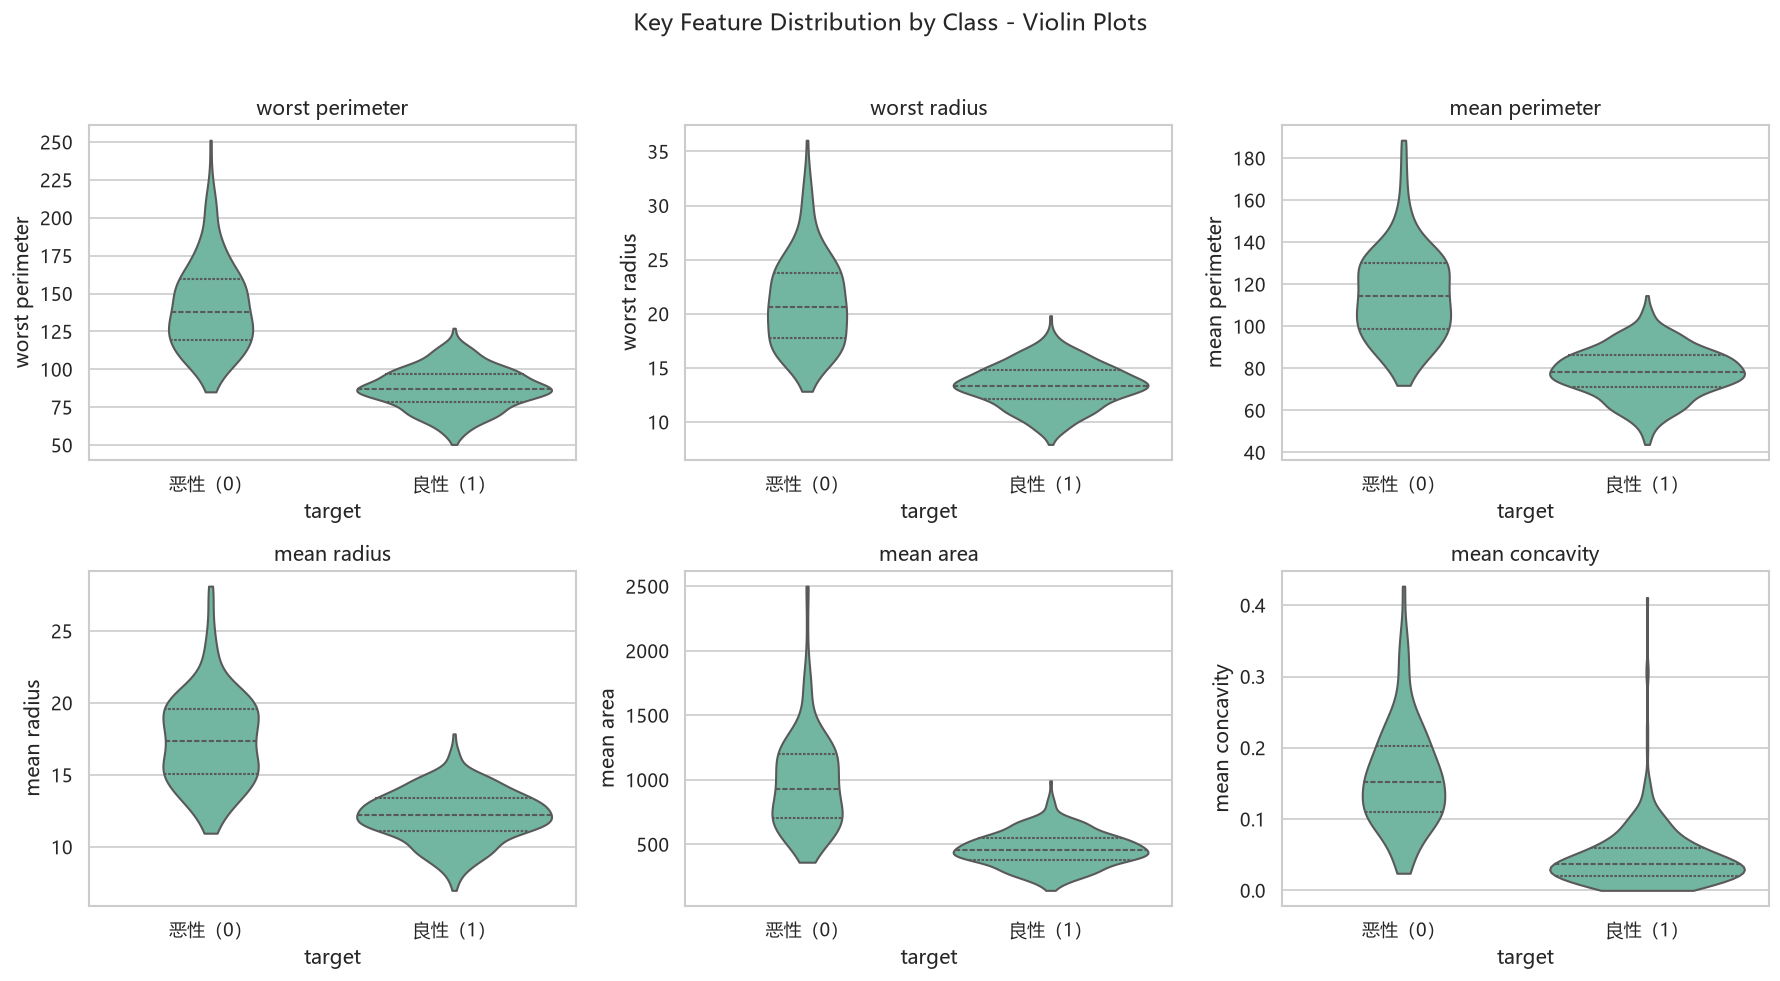

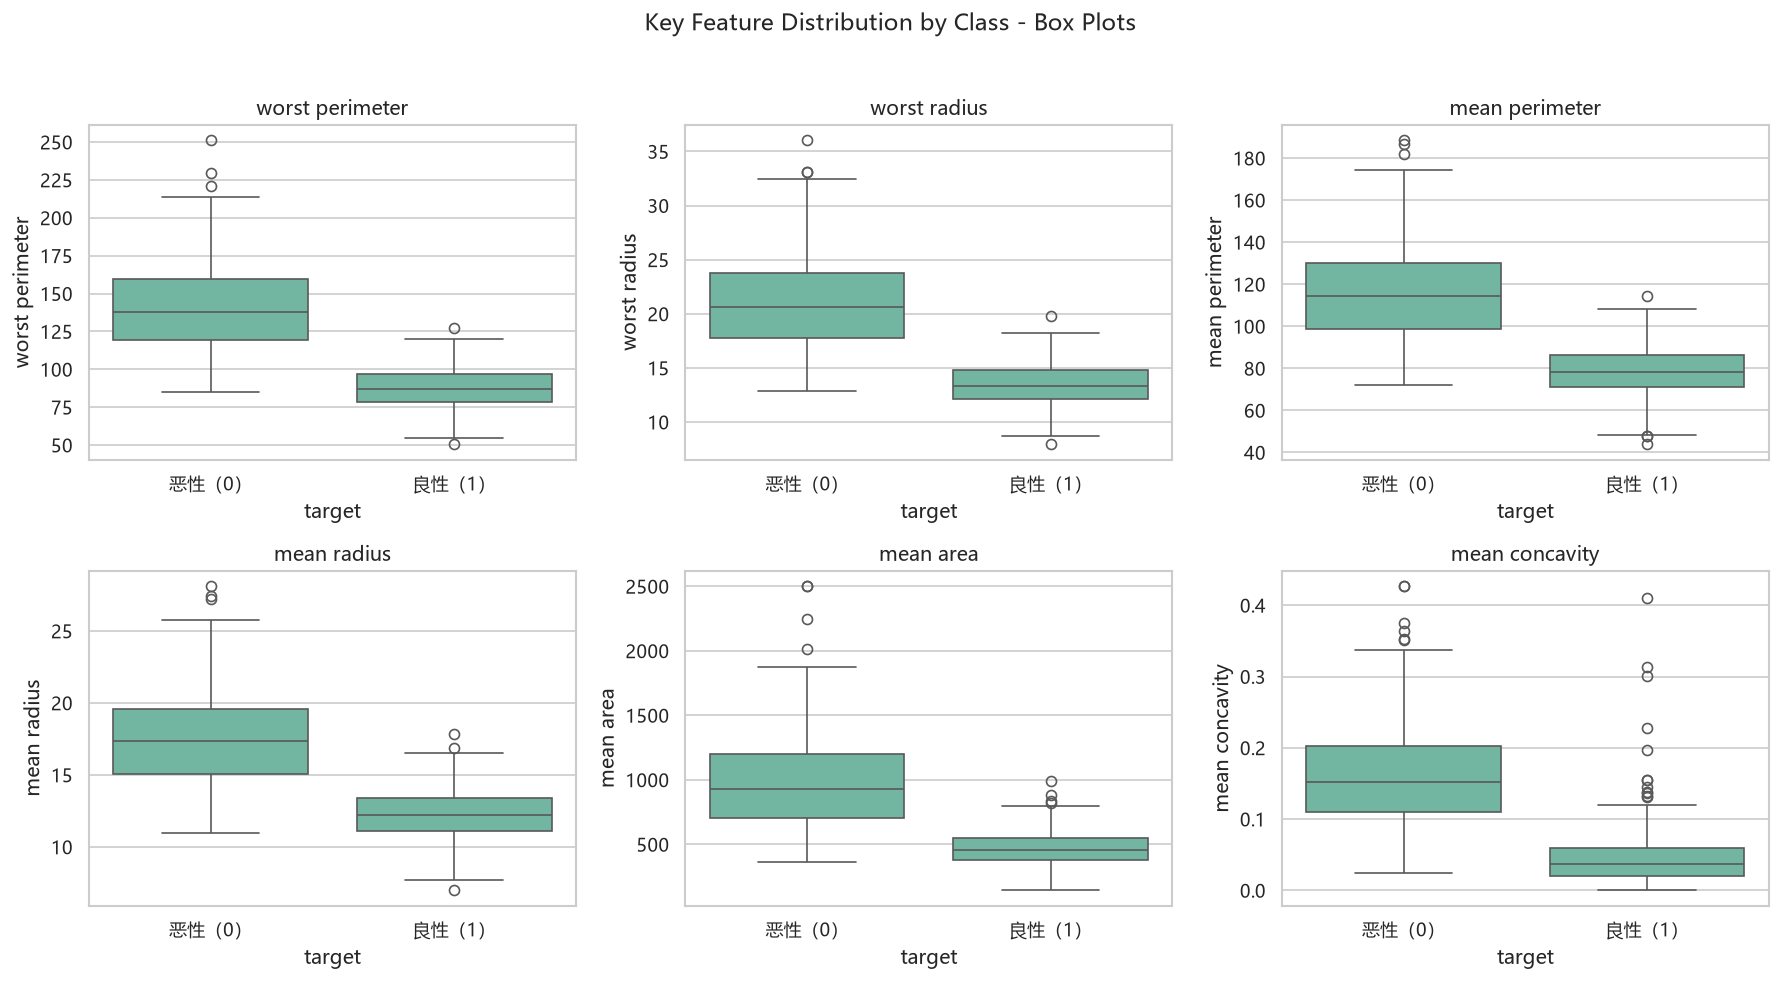

In [7]:
key_features = top_target_corr['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), key_features):
    sns.violinplot(data=df, x='target', y=feature, ax=ax, inner='quartile', cut=0)
    ax.set_xticklabels(['恶性（0）', '良性（1）'])
    ax.set_title(feature)
plt.suptitle('Key Feature Distribution by Class - Violin Plots', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), key_features):
    sns.boxplot(data=df, x='target', y=feature, ax=ax)
    ax.set_xticklabels(['恶性（0）', '良性（1）'])
    ax.set_title(feature)
plt.suptitle('Key Feature Distribution by Class - Box Plots', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 3.2 数据预处理

- 训练/测试集划分：80/20，`stratify=y` 保持类别比例，`random_state=42`。
- 标准化：`StandardScaler` 仅在训练集上 `fit`，再分别 `transform` 训练集和测试集。
- 多重共线性检查：使用 VIF，记录 `VIF > 10` 的高共线性特征；如果高 VIF 特征较多，构造一个去共线性特征集用于对照。

In [8]:
X = df.drop(columns=['target'])
y = df['target'].astype(int)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

split_summary = pd.DataFrame({
    'all': y.value_counts(normalize=True).sort_index(),
    'train': y_train.value_counts(normalize=True).sort_index(),
    'test': y_test.value_counts(normalize=True).sort_index(),
})
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
display(split_summary)

Train shape: (455, 27) Test shape: (114, 27)


,all,train,test
target,,,
0,0.372583,0.373626,0.368421
1,0.627417,0.626374,0.631579


In [9]:
def compute_vif(frame: pd.DataFrame) -> pd.DataFrame:
    imputed = pd.DataFrame(
        SimpleImputer(strategy='median').fit_transform(frame),
        columns=frame.columns,
        index=frame.index,
    )
    scaled = pd.DataFrame(StandardScaler().fit_transform(imputed), columns=imputed.columns, index=imputed.index)
    vif_rows = []
    for i, col in enumerate(scaled.columns):
        try:
            vif = variance_inflation_factor(scaled.values, i)
        except Exception:
            vif = np.inf
        vif_rows.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_table = compute_vif(X_train)
high_vif_features = vif_table.loc[vif_table['VIF'] > 10, 'feature'].tolist()
display(vif_table)
print('High VIF features (VIF > 10):', high_vif_features)

,feature,VIF
0,mean perimeter,3863.369356
1,mean radius,3498.439896
2,worst radius,364.891102
3,worst perimeter,347.848748
4,mean area,133.077170
5,perimeter error,65.721091
6,radius error,64.737267
7,mean compactness,56.743751
8,mean concavity,36.600539
9,worst compactness,36.474021


High VIF features (VIF > 10): ['mean perimeter', 'mean radius', 'worst radius', 'worst perimeter', 'mean area', 'perimeter error', 'radius error', 'mean compactness', 'mean concavity', 'worst compactness', 'area error', 'worst concavity', 'worst fractal dimension', 'worst texture', 'mean fractal dimension', 'compactness error', 'concavity error', 'mean texture', 'fractal dimension error']


In [10]:
def select_low_vif_features(vif_df: pd.DataFrame, threshold: float = 10.0):
    low_vif = vif_df.loc[vif_df['VIF'] <= threshold, 'feature'].tolist()
    if len(low_vif) >= 3:
        return low_vif
    # 如果共线性很强导致低 VIF 特征太少，则保留 VIF 最低的一半特征做对照。
    keep_n = max(3, len(vif_df) // 2)
    return vif_df.sort_values('VIF', ascending=True).head(keep_n)['feature'].tolist()

low_vif_features = select_low_vif_features(vif_table)
print('Low-collinearity feature set size:', len(low_vif_features))
print(low_vif_features)

Low-collinearity feature set size: 8
['worst symmetry', 'worst smoothness', 'mean smoothness', 'concave points error', 'symmetry error', 'mean symmetry', 'texture error', 'smoothness error']


## 3.3 基线模型：Logistic Regression

逻辑回归是线性概率模型，适合作为分类任务的性能基线。这里使用默认参数，并在标准化后的特征上训练。

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,Logistic Regression,0.973684,0.953488,0.97619,0.964706,0.99537


              precision    recall  f1-score   support

       恶性（0）       0.95      0.98      0.96        42
       良性（1）       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


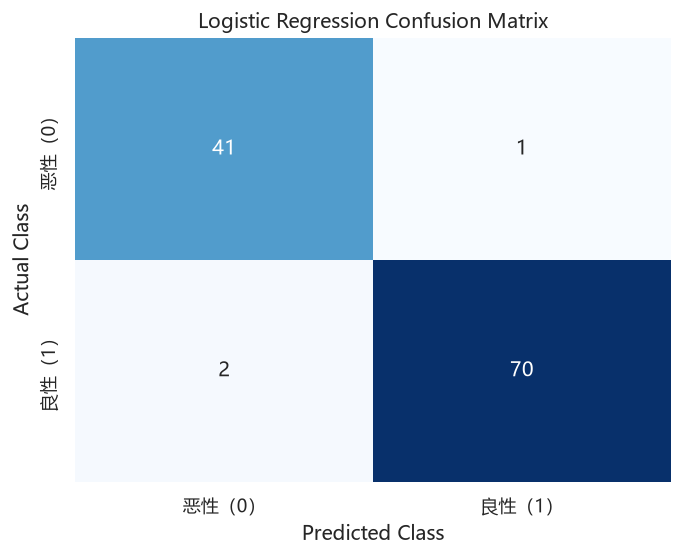

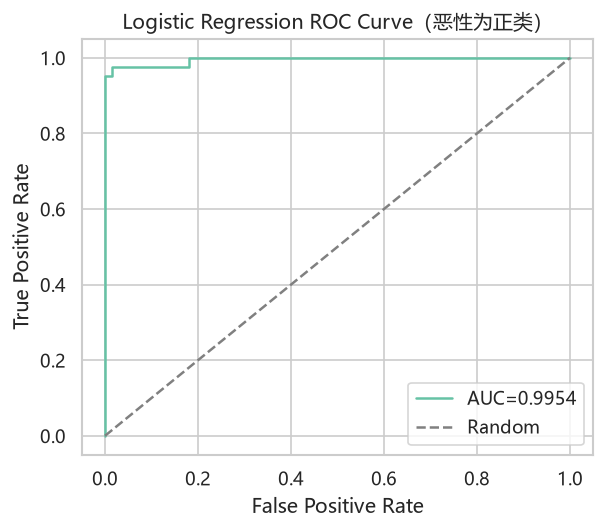

In [11]:
model_results = {}
FOCUS_LABEL = 0
FOCUS_NAME = '恶性（0）'
OTHER_NAME = '良性（1）'
CLASS_LABELS = [FOCUS_NAME, OTHER_NAME]

def get_scores(model, X_eval, positive_label=FOCUS_LABEL):
    if hasattr(model, 'predict_proba'):
        class_list = list(model.classes_)
        return model.predict_proba(X_eval)[:, class_list.index(positive_label)]
    scores = model.decision_function(X_eval)
    class_list = list(model.classes_)
    return scores if class_list[-1] == positive_label else -scores

def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_score = get_scores(model, X_eval)
    y_true_focus = (y_true == FOCUS_LABEL).astype(int)
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision（恶性）': precision_score(y_true, y_pred, pos_label=FOCUS_LABEL, zero_division=0),
        'Recall（恶性）': recall_score(y_true, y_pred, pos_label=FOCUS_LABEL, zero_division=0),
        'F1（恶性）': f1_score(y_true, y_pred, pos_label=FOCUS_LABEL, zero_division=0),
        'ROC-AUC（恶性）': roc_auc_score(y_true_focus, y_score),
    }
    return metrics, y_pred, y_score

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    plt.title(title)
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.show()

def plot_single_roc(y_true, y_score, title):
    y_true_focus = (y_true == FOCUS_LABEL).astype(int)
    fpr, tpr, _ = roc_curve(y_true_focus, y_score)
    auc = roc_auc_score(y_true_focus, y_score)
    plt.figure(figsize=(5.5, 4.5))
    plt.plot(fpr, tpr, label=f'AUC={auc:.4f}')
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.show()

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
metrics, y_pred, y_score = evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)
model_results['Logistic Regression'] = {'model': log_reg, 'metrics': metrics, 'pred': y_pred, 'score': y_score, 'X_eval': X_test_scaled}
display(pd.DataFrame([metrics]))
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=CLASS_LABELS))
plot_confusion(y_test, y_pred, 'Logistic Regression Confusion Matrix')
plot_single_roc(y_test, y_score, 'Logistic Regression ROC Curve（恶性为正类）')


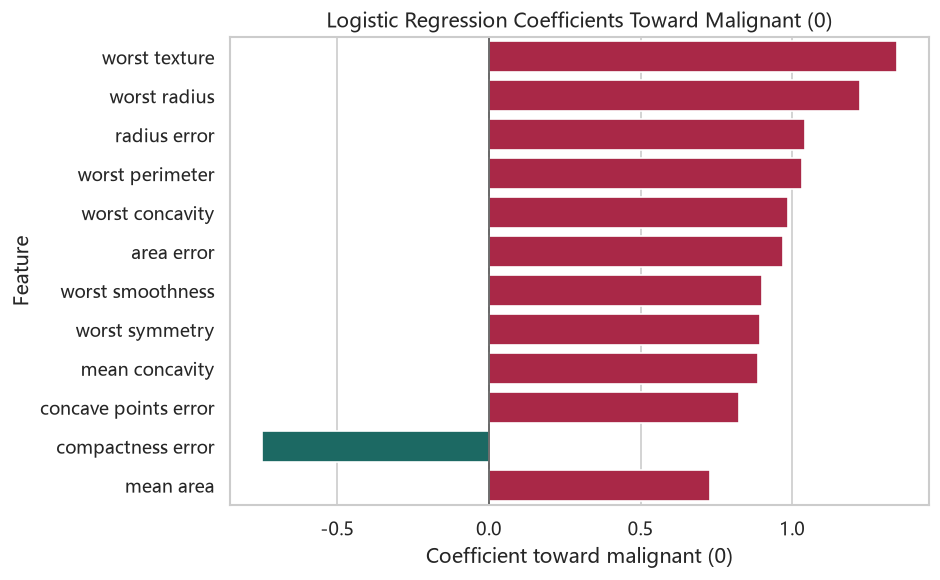

,feature,coefficient_to_malignant,abs_coefficient
20,worst texture,1.345770,1.345770
19,worst radius,1.224056,1.224056
9,radius error,1.043625,1.043625
21,worst perimeter,1.032060,1.032060
24,worst concavity,0.986201,0.986201
12,area error,0.969539,0.969539
22,worst smoothness,0.900990,0.900990
25,worst symmetry,0.894961,0.894961
6,mean concavity,0.887408,0.887408
16,concave points error,0.826023,0.826023


In [12]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    # sklearn binary LogisticRegression.coef_ is the log-odds of class=1 vs class=0.
    # This project focuses on malignant class 0, so negate it to describe coefficients toward malignant (0).
    'coefficient_to_malignant': -log_reg.coef_[0],
})
coef_df['abs_coefficient'] = coef_df['coefficient_to_malignant'].abs()
coef_top = coef_df.sort_values('abs_coefficient', ascending=False).head(12)

plt.figure(figsize=(8, 5))
colors = np.where(coef_top['coefficient_to_malignant'] >= 0, '#BE123C', '#0F766E')
sns.barplot(data=coef_top, x='coefficient_to_malignant', y='feature', palette=colors)
plt.axvline(0, color='#555', linewidth=1)
plt.title('Logistic Regression Coefficients Toward Malignant (0)')
plt.xlabel('Coefficient toward malignant (0)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(coef_top)


## 3.4 线性模型进阶：SVM

`SVC(probability=True)` 默认使用 RBF 核，可以表达非线性决策边界。与 Logistic Regression 相比，SVM 的概率输出来自额外概率校准过程，训练成本也通常更高。

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,SVM,0.982456,0.97619,0.97619,0.97619,0.99504


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



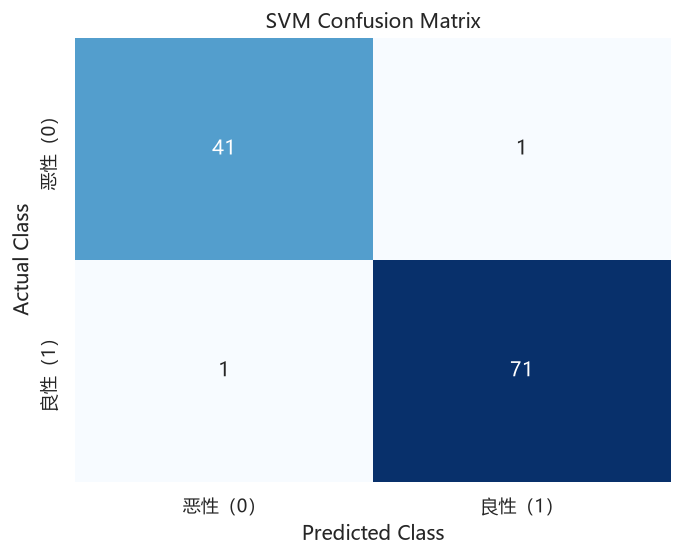

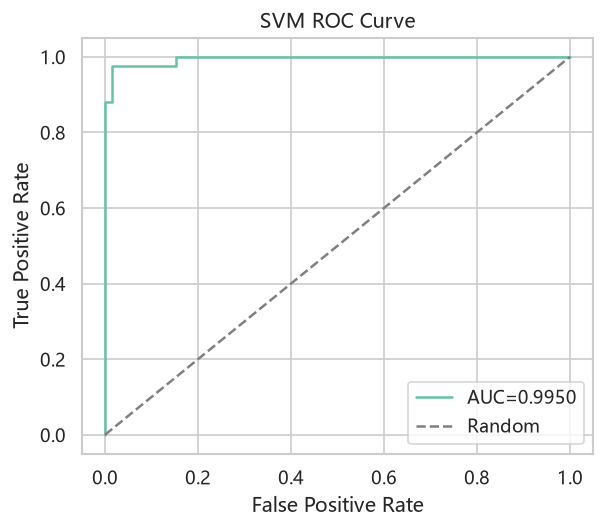

In [13]:
svm = SVC(probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
metrics, y_pred, y_score = evaluate_model('SVM', svm, X_test_scaled, y_test)
model_results['SVM'] = {'model': svm, 'metrics': metrics, 'pred': y_pred, 'score': y_score, 'X_eval': X_test_scaled}
display(pd.DataFrame([metrics]))
print(classification_report(y_test, y_pred))
plot_confusion(y_test, y_pred, 'SVM Confusion Matrix')
plot_single_roc(y_test, y_score, 'SVM ROC Curve')

## 3.5 树模型：Random Forest

随机森林通过多棵决策树集成来降低单棵树过拟合风险。树模型可捕捉非线性和特征交互，通常比线性模型更灵活，但解释性更弱。

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,Random Forest,0.947368,0.928571,0.928571,0.928571,0.991071


              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



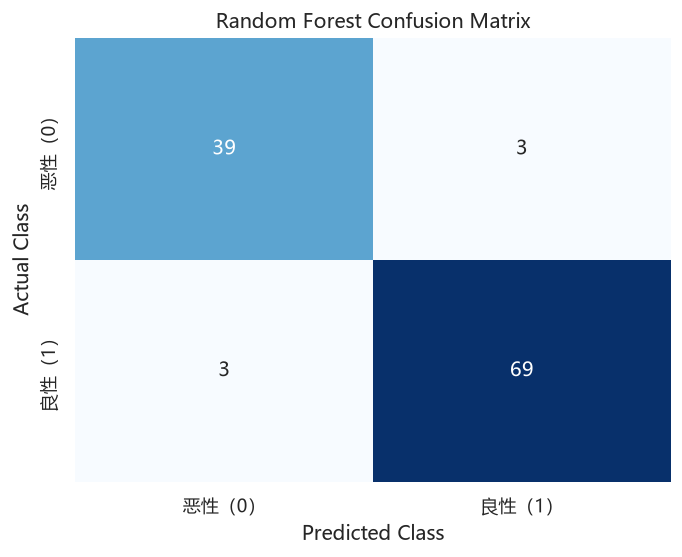

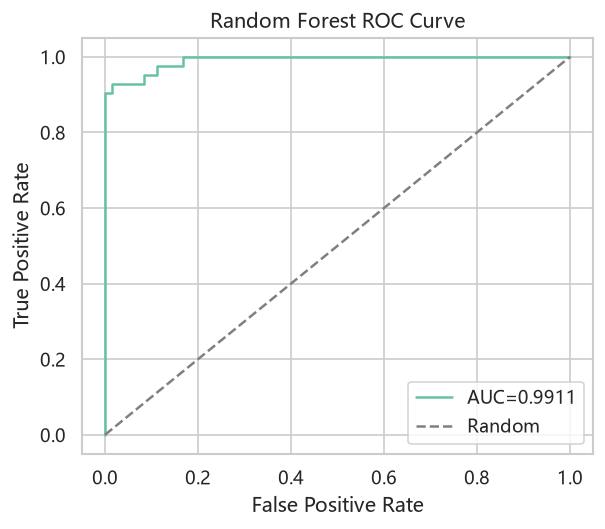

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
metrics, y_pred, y_score = evaluate_model('Random Forest', rf, X_test, y_test)
model_results['Random Forest'] = {'model': rf, 'metrics': metrics, 'pred': y_pred, 'score': y_score, 'X_eval': X_test}
display(pd.DataFrame([metrics]))
print(classification_report(y_test, y_pred))
plot_confusion(y_test, y_pred, 'Random Forest Confusion Matrix')
plot_single_roc(y_test, y_score, 'Random Forest ROC Curve')

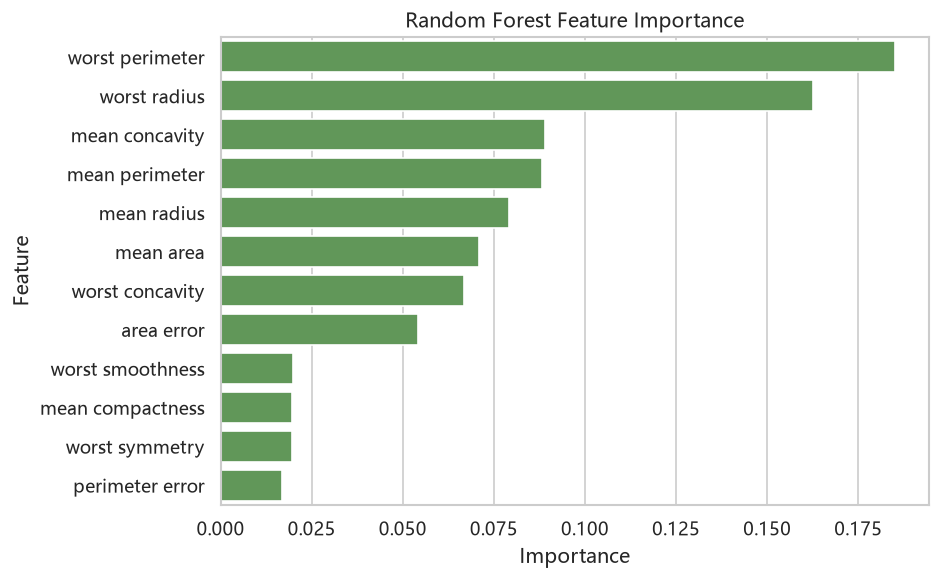

,feature,importance
21,worst perimeter,0.185099
19,worst radius,0.162576
6,mean concavity,0.088987
2,mean perimeter,0.088173
0,mean radius,0.079236
3,mean area,0.071043
24,worst concavity,0.066673
12,area error,0.054128
22,worst smoothness,0.019994
5,mean compactness,0.019624


In [15]:
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x='importance', y='feature', color='#59A14F')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(rf_importance)

## 3.6 集成学习：XGBoost

XGBoost 是 boosting 集成模型，逐轮训练新树来修正前面模型的错误。与 Random Forest 的 bagging 思路不同，boosting 更强调序列式误差修正。

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,XGBoost,0.947368,0.95,0.904762,0.926829,0.991733


              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



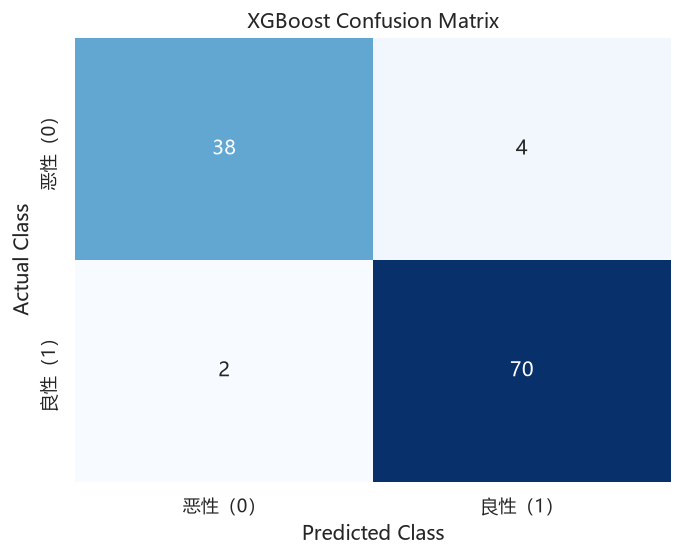

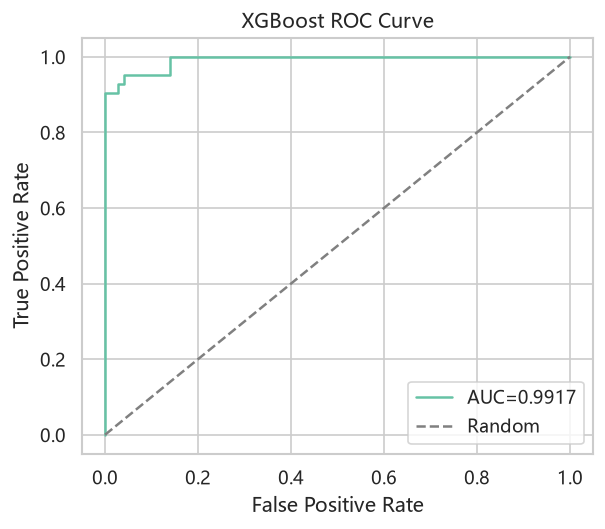

In [16]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)
metrics, y_pred, y_score = evaluate_model('XGBoost', xgb_model, X_test, y_test)
model_results['XGBoost'] = {'model': xgb_model, 'metrics': metrics, 'pred': y_pred, 'score': y_score, 'X_eval': X_test}
display(pd.DataFrame([metrics]))
print(classification_report(y_test, y_pred))
plot_confusion(y_test, y_pred, 'XGBoost Confusion Matrix')
plot_single_roc(y_test, y_score, 'XGBoost ROC Curve')

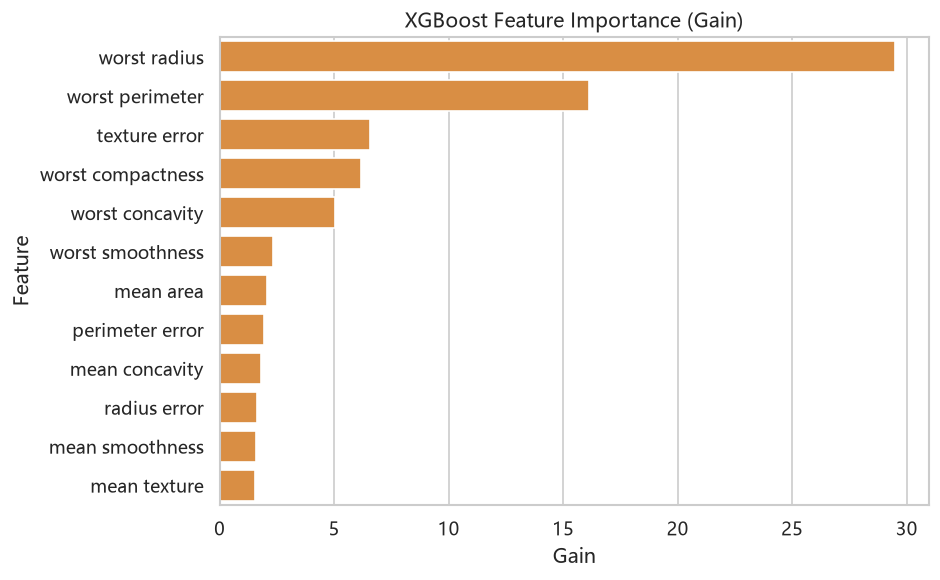

,feature,gain
17,worst radius,29.490442
19,worst perimeter,16.143179
9,texture error,6.577373
21,worst compactness,6.177499
22,worst concavity,5.036226
20,worst smoothness,2.310098
2,mean area,2.050359
10,perimeter error,1.941673
5,mean concavity,1.799842
8,radius error,1.624445


In [17]:
booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type='gain')
xgb_importance = pd.DataFrame({
    'feature': list(gain_scores.keys()),
    'gain': list(gain_scores.values()),
}).sort_values('gain', ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance, x='gain', y='feature', color='#F28E2B')
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Gain')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(xgb_importance)

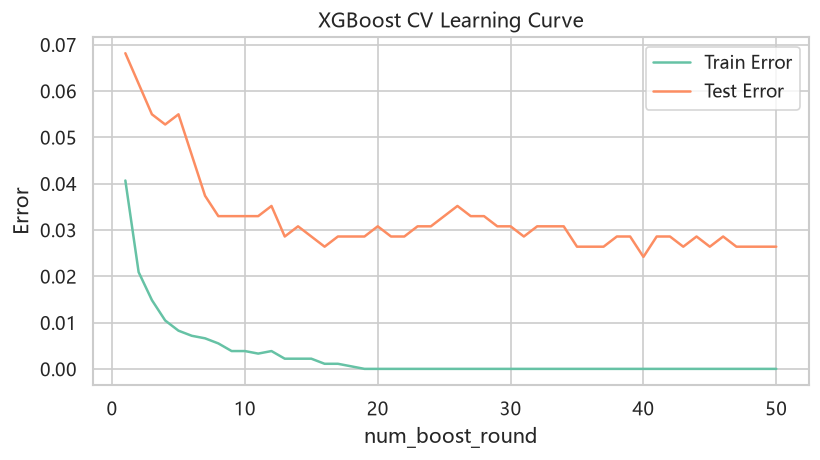

,train-error-mean,train-error-std,test-error-mean,test-error-std
45,0.0,0.0,0.028571,0.011207
46,0.0,0.0,0.026374,0.013187
47,0.0,0.0,0.026374,0.013187
48,0.0,0.0,0.026374,0.013187
49,0.0,0.0,0.026374,0.013187


In [18]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'error',
    'seed': RANDOM_STATE,
}
cv_results = xgb.cv(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=50,
    nfold=5,
    stratified=True,
    seed=RANDOM_STATE,
    verbose_eval=False,
)

plt.figure(figsize=(7, 4))
plt.plot(cv_results.index + 1, cv_results['train-error-mean'], label='Train Error')
plt.plot(cv_results.index + 1, cv_results['test-error-mean'], label='Test Error')
plt.xlabel('num_boost_round')
plt.ylabel('Error')
plt.title('XGBoost CV Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()
display(cv_results.tail())

## 3.7 全模型汇总对比

汇总 Logistic Regression、SVM、Random Forest、XGBoost 的 Accuracy、Precision、Recall、F1 和 ROC-AUC，并绘制四条 ROC 曲线。

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,Logistic Regression,0.9737,0.9535,0.9762,0.9647,0.9954
1,SVM,0.9825,0.9762,0.9762,0.9762,0.9950
3,XGBoost,0.9474,0.9500,0.9048,0.9268,0.9917
2,Random Forest,0.9474,0.9286,0.9286,0.9286,0.9911


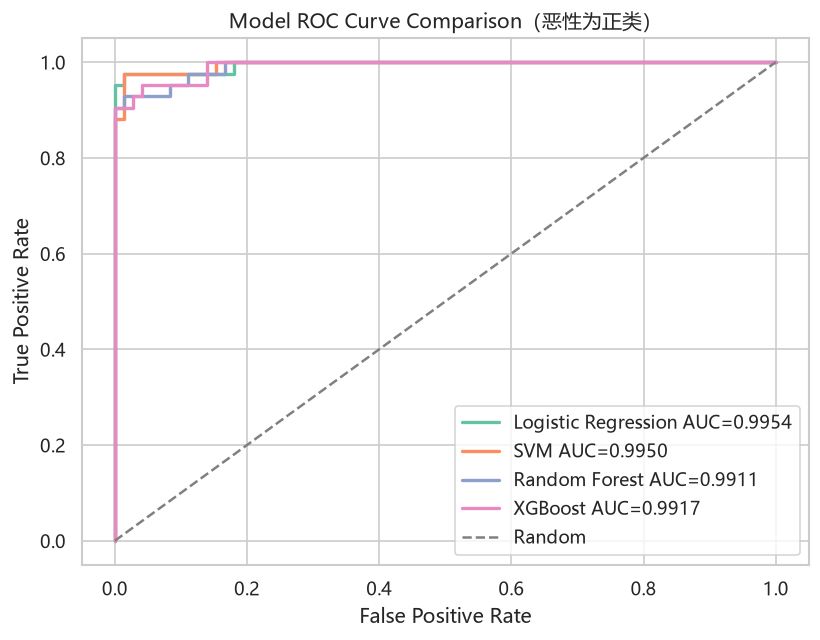

Best baseline model by malignant ROC-AUC: Logistic Regression


In [19]:
metrics_table = pd.DataFrame([v['metrics'] for v in model_results.values()]).sort_values('ROC-AUC（恶性）', ascending=False)
display(metrics_table.style.format({
    'Accuracy': '{:.4f}',
    'Precision（恶性）': '{:.4f}',
    'Recall（恶性）': '{:.4f}',
    'F1（恶性）': '{:.4f}',
    'ROC-AUC（恶性）': '{:.4f}',
}))

plt.figure(figsize=(7, 5.5))
y_test_focus = (y_test == FOCUS_LABEL).astype(int)
for name, result in model_results.items():
    fpr, tpr, _ = roc_curve(y_test_focus, result['score'])
    auc = roc_auc_score(y_test_focus, result['score'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} AUC={auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model ROC Curve Comparison（恶性为正类）')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = metrics_table.iloc[0]['Model']
print('Best baseline model by malignant ROC-AUC:', best_model_name)


## 4. 最佳模型超参数调优

根据全模型对比中的 ROC-AUC 自动选择最佳基线模型，并使用 `GridSearchCV` 进行调优。交叉验证采用 `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`，评分指标为 `roc_auc`。

Best model: Logistic Regression
Best CV AUC: 0.995252837977296
Best params: {'model__C': 1, 'model__penalty': 'l2'}


,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,Tuned Logistic Regression,0.973684,0.953488,0.97619,0.964706,0.99537


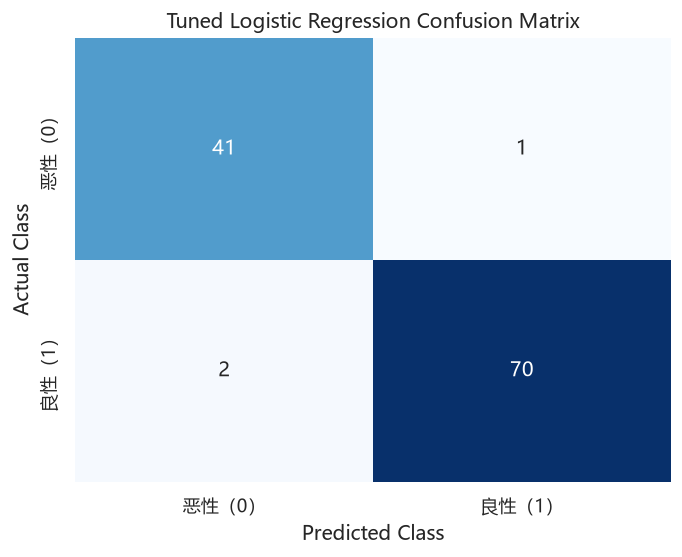

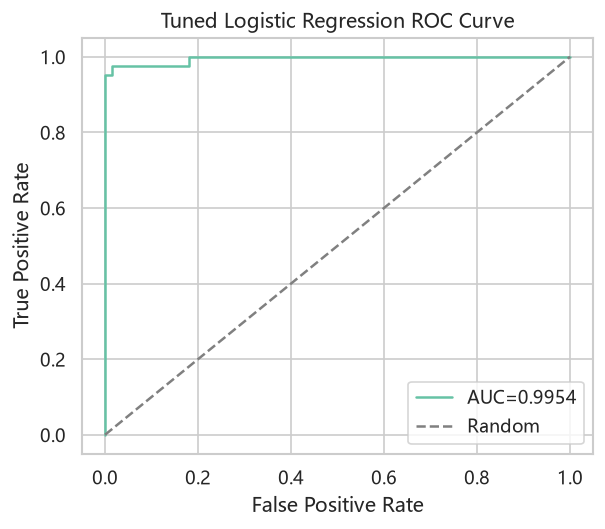

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    'Logistic Regression': {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2'],
        },
        'X_train': X_train,
        'X_test': X_test,
    },
    'SVM': {
        'estimator': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', SVC(probability=True, random_state=RANDOM_STATE)),
        ]),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__gamma': ['scale', 0.01, 0.1],
        },
        'X_train': X_train,
        'X_test': X_test,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 3, 5],
            'min_samples_leaf': [1, 3, 5],
        },
        'X_train': X_train,
        'X_test': X_test,
    },
    'XGBoost': {
        'estimator': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [2, 3, 4],
            'learning_rate': [0.03, 0.1],
            'subsample': [0.8, 1.0],
        },
        'X_train': X_train,
        'X_test': X_test,
    },
}

selected = search_spaces[best_model_name]
grid = GridSearchCV(
    estimator=selected['estimator'],
    param_grid=selected['params'],
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    refit=True,
)
grid.fit(selected['X_train'], y_train)

tuned_model = grid.best_estimator_
tuned_metrics, tuned_pred, tuned_score = evaluate_model(
    f'Tuned {best_model_name}', tuned_model, selected['X_test'], y_test
)

print('Best model:', best_model_name)
print('Best CV AUC:', grid.best_score_)
print('Best params:', grid.best_params_)
display(pd.DataFrame([tuned_metrics]))
plot_confusion(y_test, tuned_pred, f'Tuned {best_model_name} Confusion Matrix')
plot_single_roc(y_test, tuned_score, f'Tuned {best_model_name} ROC Curve')

## 5. 模型解释性分析

本节补充三类解释性结果：逻辑回归系数、随机森林/XGBoost 特征重要性，以及最终最佳模型的 permutation importance。注意：这些结果代表模型统计贡献，不代表医学因果关系。

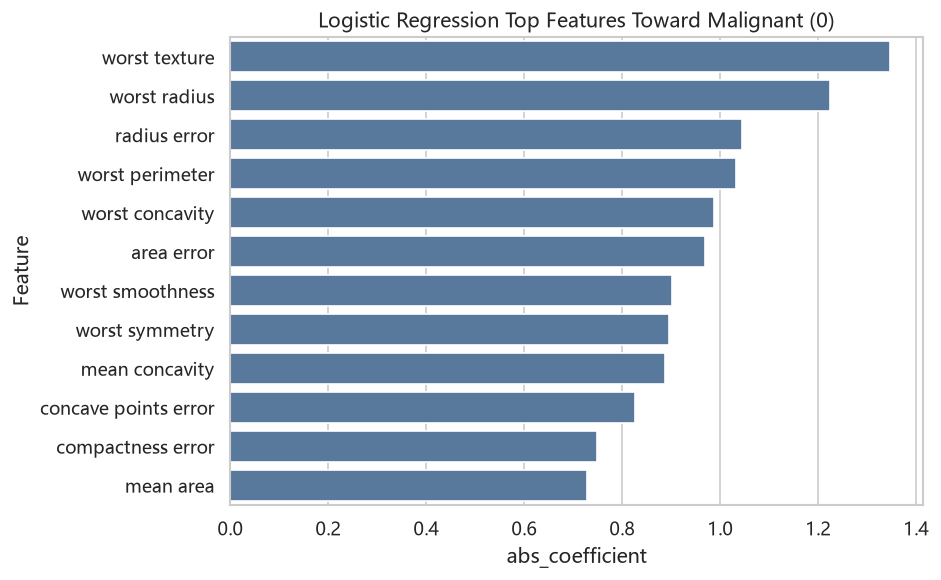

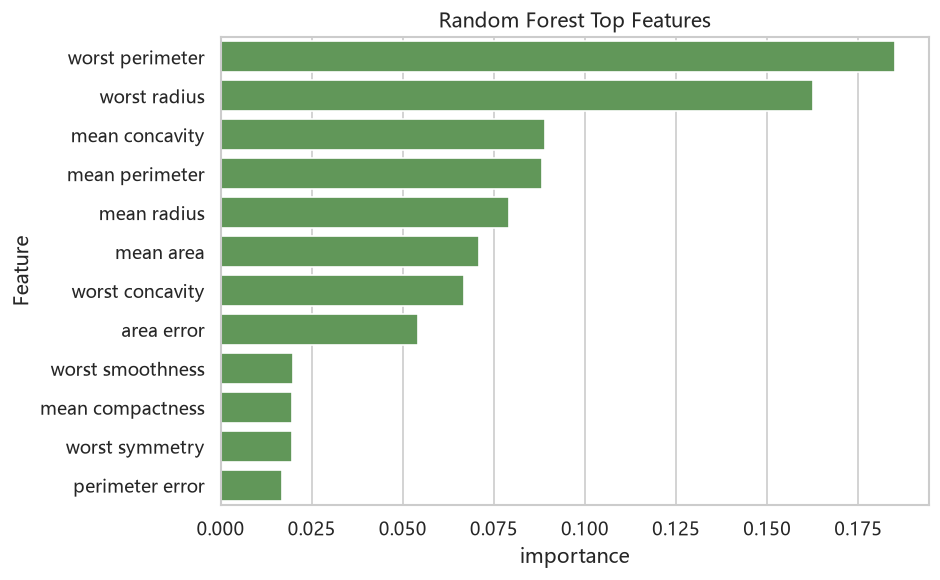

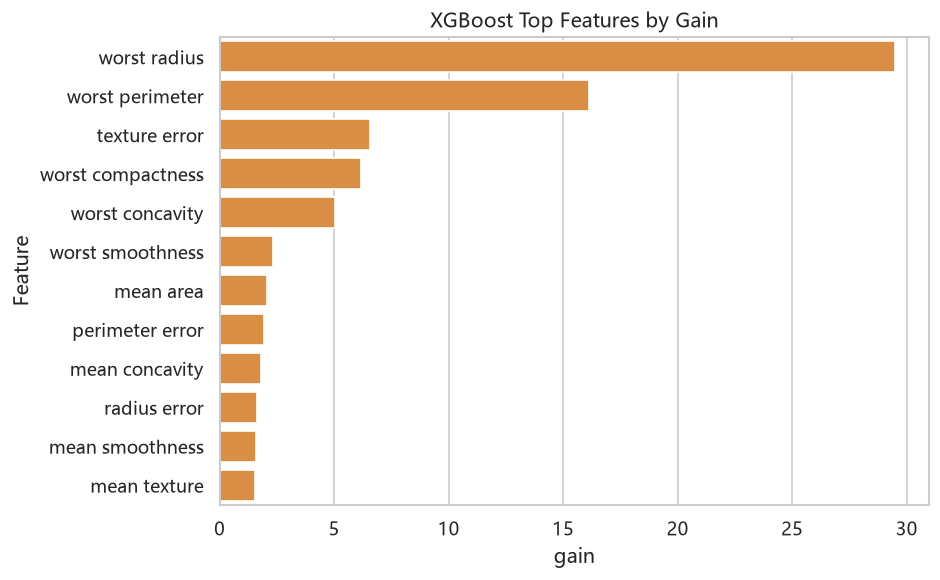

In [21]:
def plot_importance_table(data, value_col, title, color):
    plt.figure(figsize=(8, 5))
    sns.barplot(data=data.head(12), x=value_col, y='feature', color=color)
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_importance_table(coef_df.sort_values('abs_coefficient', ascending=False), 'abs_coefficient', 'Logistic Regression Top Features Toward Malignant (0)', '#4C78A8')
plot_importance_table(pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False), 'importance', 'Random Forest Top Features', '#59A14F')
plot_importance_table(xgb_importance, 'gain', 'XGBoost Top Features by Gain', '#F28E2B')


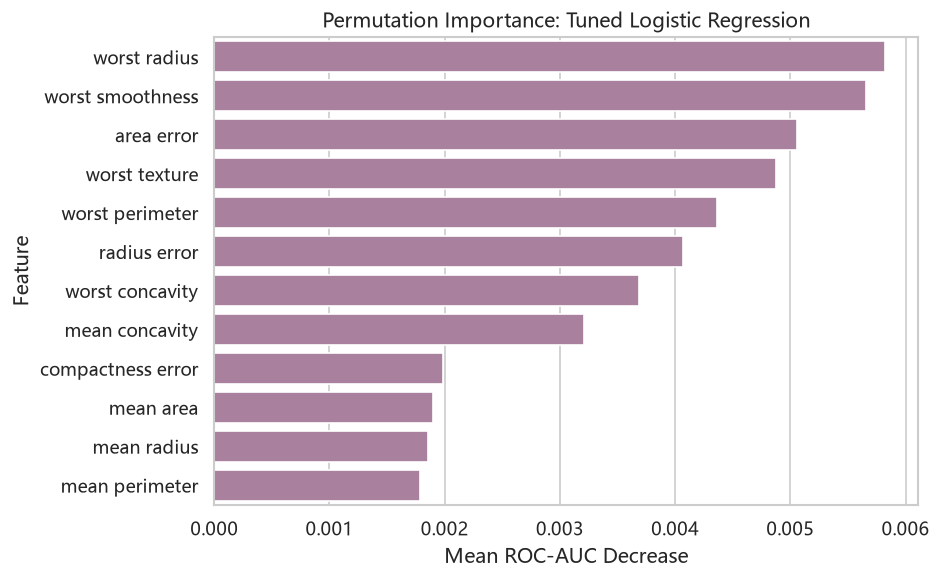

,feature,importance_mean,importance_std
19,worst radius,0.005820,0.003442
22,worst smoothness,0.005655,0.002437
12,area error,0.005060,0.003054
20,worst texture,0.004878,0.003809
21,worst perimeter,0.004365,0.002959
9,radius error,0.004067,0.002521
24,worst concavity,0.003687,0.001982
6,mean concavity,0.003208,0.001680
14,compactness error,0.001984,0.001259
3,mean area,0.001901,0.002145


In [22]:
perm = permutation_importance(
    tuned_model,
    selected['X_test'],
    y_test,
    scoring='roc_auc',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=perm_df.head(12), x='importance_mean', y='feature', color='#B07AA1')
plt.title(f'Permutation Importance: Tuned {best_model_name}')
plt.xlabel('Mean ROC-AUC Decrease')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(perm_df.head(12))

## 6. 去共线性对照实验

如果 VIF 显示多个特征存在严重共线性，可以使用低共线性特征集进行一次 Logistic Regression 对照。该对照帮助观察强相关特征对线性模型稳定性和性能的影响。

In [23]:
if len(high_vif_features) > 1:
    lr_low_vif = LogisticRegression()
    lr_low_vif.fit(X_train_scaled[low_vif_features], y_train)
    low_vif_metrics, low_vif_pred, low_vif_score = evaluate_model(
        'Logistic Regression (Low VIF)',
        lr_low_vif,
        X_test_scaled[low_vif_features],
        y_test,
    )
    display(pd.DataFrame([model_results['Logistic Regression']['metrics'], low_vif_metrics]))
else:
    print('High VIF features are not enough to run a meaningful low-collinearity comparison.')

,Model,Accuracy,Precision（恶性）,Recall（恶性）,F1（恶性）,ROC-AUC（恶性）
0,Logistic Regression,0.973684,0.953488,0.976190,0.964706,0.995370
1,Logistic Regression (Low VIF),0.824561,0.761905,0.761905,0.761905,0.891534


## 7. 结论

本 Notebook 完成了乳腺肿瘤细胞核特征二分类的完整建模流程。模型评估中，ROC-AUC 衡量模型区分两类样本的整体能力；Recall 在医学类问题中通常尤其重要，因为它反映真实正类被识别出来的比例；Precision 则反映预测为正类样本的可靠程度。

后续可以进一步加入外部验证集、概率校准、SHAP 解释和更系统的超参数搜索，以提升模型稳定性和可解释性。